In [1]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df=pd.read_csv("drug.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=200, step=1)
All columns are
0 age
1 sex
2 bp
3 cholesterol
4 Na_to_K
5 drug


In [3]:
df.shape

(200, 6)

In [4]:
df.head()

,age,sex,bp,cholesterol,Na_to_K,drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [5]:
df.sample(n=10)

,age,sex,bp,cholesterol,Na_to_K,drug
104,22,M,HIGH,NORMAL,28.294,drugY
19,32,F,HIGH,NORMAL,25.974,drugY
115,51,M,HIGH,HIGH,18.295,drugY
48,23,M,NORMAL,HIGH,31.686,drugY
142,60,M,HIGH,NORMAL,8.621,drugB
158,59,F,LOW,HIGH,10.444,drugC
10,47,F,LOW,HIGH,11.767,drugC
190,58,M,HIGH,HIGH,18.991,drugY
72,24,F,NORMAL,HIGH,10.605,drugX
124,53,F,HIGH,NORMAL,12.495,drugB


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          200 non-null    int64  
 1   sex          200 non-null    object 
 2   bp           200 non-null    object 
 3   cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [7]:
df.isnull()

,age,sex,bp,cholesterol,Na_to_K,drug
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
195,False,False,False,False,False,False
196,False,False,False,False,False,False
197,False,False,False,False,False,False
198,False,False,False,False,False,False


In [8]:
print(df.isnull().sum())
print("The data seems to not have any null values")

age            0
sex            0
bp             0
cholesterol    0
Na_to_K        0
drug           0
dtype: int64
The data seems to not have any null values


In [9]:
df.describe()

,age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [10]:
# function for calculating which product occur multiple times and how much time it occur
def duplicates(column_name):
    counts = df[column_name].value_counts()
    duplicates = counts[counts > 1]
    result = duplicates.reset_index()
    result.columns = [column_name, 'Count']
    print(result)

duplicates("sex")
print()
duplicates("bp")
print()
duplicates("cholesterol")
print()
duplicates("drug")

  sex  Count
0   M    104
1   F     96

       bp  Count
0    HIGH     77
1     LOW     64
2  NORMAL     59

  cholesterol  Count
0        HIGH    103
1      NORMAL     97

    drug  Count
0  drugY     91
1  drugX     54
2  drugA     23
3  drugC     16
4  drugB     16


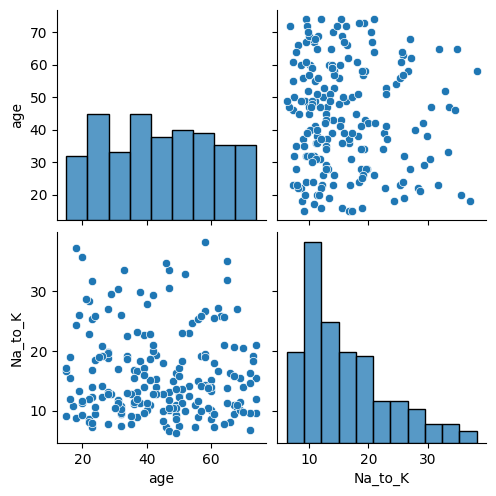

In [11]:
grid = sns.pairplot(df)

In [12]:
'''

grid.savefig('drugpairplot.png', dpi=300, bbox_inches='tight')

'''

"\n\ngrid.savefig('drugpairplot.png', dpi=300, bbox_inches='tight')\n\n"

<Axes: >

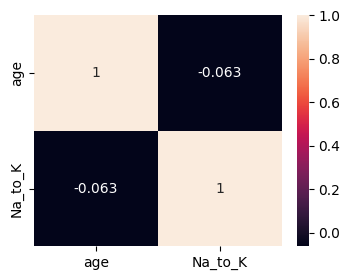

In [13]:
plt.figure(figsize=(4,3))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [17]:
# label encoding
le = LabelEncoder()
al = df
al['sex'] = le.fit_transform(al['sex'])
al['bp'] = le.fit_transform(al['bp'])
al['cholesterol'] = le.fit_transform(al['cholesterol'])
al['drug'] = le.fit_transform(al['drug'])
print(al)

     age  sex  bp  cholesterol  Na_to_K  drug
0     23    0   0            0   25.355     4
1     47    1   1            0   13.093     2
2     47    1   1            0   10.114     2
3     28    0   2            0    7.798     3
4     61    0   1            0   18.043     4
..   ...  ...  ..          ...      ...   ...
195   56    0   1            0   11.567     2
196   16    1   1            0   12.006     2
197   52    1   2            0    9.894     3
198   23    1   2            1   14.020     3
199   40    0   1            1   11.349     3

[200 rows x 6 columns]


<Axes: >

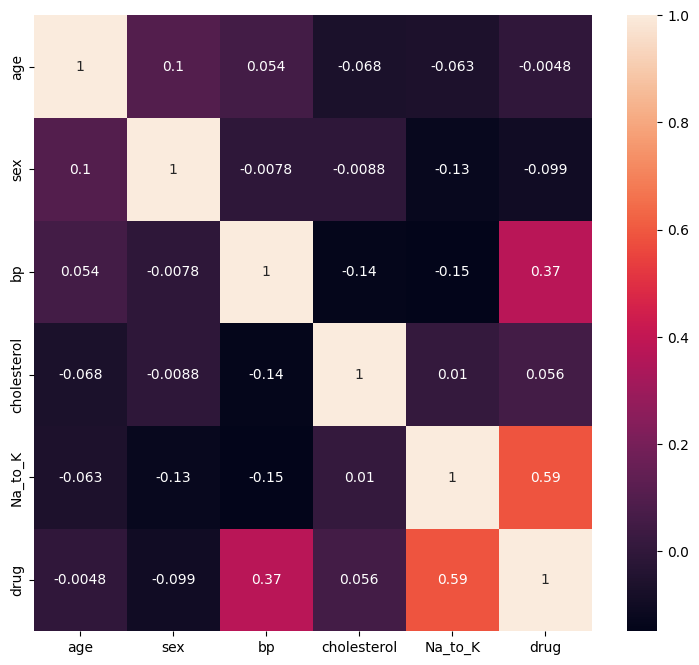

In [20]:
plt.figure(figsize=(9,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)